# Κατεβάζουμε τα αρχεία

In [102]:
from gdown import download
download(id='1ecv7SSUCy6v35106oxqf7F4BvZOSdR2L', output='rubiks.jpg')
download(id='1w43BI_6ZngVDD6NHZ4OYE16q0ULTbJal', output='cat.jpg')

Downloading...
From: https://drive.google.com/uc?id=1ecv7SSUCy6v35106oxqf7F4BvZOSdR2L
To: d:\projects\Supervised-Learning-Experiments\challenges\rubiks.jpg
100%|██████████| 50.0k/50.0k [00:00<00:00, 346kB/s]
Downloading...
From: https://drive.google.com/uc?id=1w43BI_6ZngVDD6NHZ4OYE16q0ULTbJal
To: d:\projects\Supervised-Learning-Experiments\challenges\cat.jpg
100%|██████████| 12.6k/12.6k [00:00<00:00, 491kB/s]


'cat.jpg'

# **Χρωματισμός Τετραγώνου**

  Θέλουμε να χρωματίσουμε ένα τετράγωνο πλευράς 1. Για να γίνει αυτό, θα χρησιμοποιήσουμε μια συνάρτηση που αντιστοιχίζει σε κάθε σημείο $(x,y)$ με $0 \le x,y \le 1$, τρεις τιμές χρωματικής φωτεινότητας $(r, g, b)$ με $0 \le r, g, b \le 1$ που αντιστοιχούν στην κόκκινη, στην πράσινη και στην μπλέ συνιστώσα.

<p align="center">
  
</p>


  Για παράδειγμα, η συνάρτηση $f(x,y) = (x,y,0)$ βάφει:
- το σημείο $(x,y) = (0,0)$ μαύρο, δλδ $(r,g,b) = (0,0,0)$,
- το σημείο $(x,y) = (1,0)$ κόκκινο, δλδ $(r,g,b) = (1,0,0)$,
- το σημείο $(x,y) = (0,1)$ πράσινο, δλδ $(r,g,b) = (0,1,0)$,
- το σημείο $(x,y) = (1,1)$ κίτρινο, δλδ $(r,g,b) = (1,1,0)$ συνδυάζοντας την κόκκινη και πράσινη συνιστώσα
- κάθε άλλο σημείο ένα μείγμα αυτών των χρωμάτων.



Η μέθοδος `function2image` μετατρέπει μια δοσμένη συνάρτηση σε εικόνα.


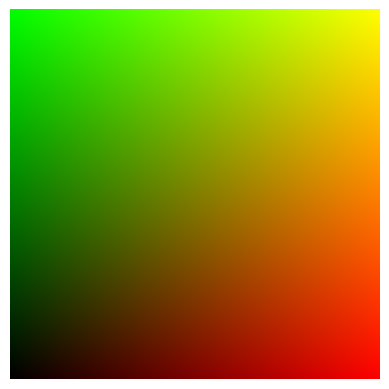

In [103]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import types
import math

def function2image(f, grid_size=500):
    x_vals = torch.linspace(0, 1, grid_size)
    y_vals = torch.linspace(0, 1, grid_size)
    X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')

    X_flat = X.flatten()
    Y_flat = Y.flatten()

    if isinstance(f, types.FunctionType):
        output = torch.tensor([f(x.item(), y.item()) for x, y in zip(X_flat, Y_flat)])
    elif isinstance(f, torch.nn.Module):
        inp = torch.column_stack( (X_flat, Y_flat) )
        output = f( inp ).detach()
    else:
        print("Unsupported function")
        return

    output_image = output.clamp(0, 1).view(grid_size, grid_size, 3)

    plt.imshow(output_image.numpy(), origin="lower")
    plt.axis('off')
    plt.show()

def basic_f(x, y):
    return (x, y, 0)

def easy_f(x, y):
    return (0, 0, abs(x+y - 1))

def medium_f(x, y):
    return ((math.sin(x*15)) * 0.5 +0.5,(math.cos(y*15)) * 0.5+0.5,0)

function2image(basic_f)

## Πιο δύσκολες συναρτήσεις με βάση φωτογραφίες

torch.Size([3, 225, 225])


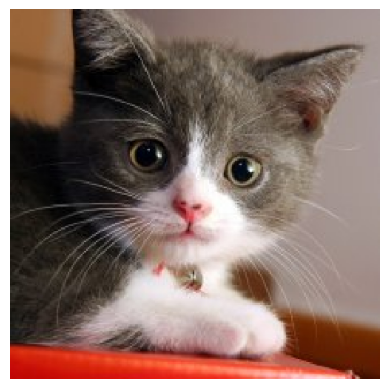

In [104]:
from PIL import Image
from torchvision import transforms as T

advanced_img = T.ToTensor()(Image.open("rubiks.jpg").convert("RGB"))
def advanced_f(x, y):
    h, w = advanced_img.shape[1], advanced_img.shape[2]
    xi = min(math.floor(x * w), w - 1)
    yi = min(math.floor((1-y) * h), h - 1)
    return advanced_img[:, yi, xi].tolist()

hard_img = T.ToTensor()(Image.open("cat.jpg").convert("RGB"))
print(hard_img.size())
def hard_f(x, y):
    h, w = hard_img.shape[1], hard_img.shape[2]
    xi = min(math.floor(x * w), w - 1)
    yi = min(math.floor((1-y) * h), h - 1)
    return hard_img[:, yi, xi].tolist()


function2image(hard_f)

## Η άσκηση

Για την άσκηση θα χρησιμοποιήσουμε μια δοσμένη αρχιτεκτονική νεωρωνικού δικτύου ως συνάρτηση για να χρωματίσουμε το τετράγωνο. Το νευρωνικό δέχεται 2 εισόδους τις συντεταγμένες $(x,y)$ και βγάζει ως έξοδο 3 τιμές που αντιστοιχούν στις φωτεινότητες rgb. Στόχος σας είναι να εκπαιδεύσετε μια τέτοια αρχιτεκτονική για κάθε εικόνα έτσι ώστε να οδηγήσει σε όσο πιο πιστή αναπαράσταση της εικόνας μπορείτε.


<p align="center">
  
</p>


 Παρακάτω δίνεται η αρχιτεκτονική και η οπτικοποίηση του νευρωνικού με τυχαία αρχικοποιημένα βάρη.

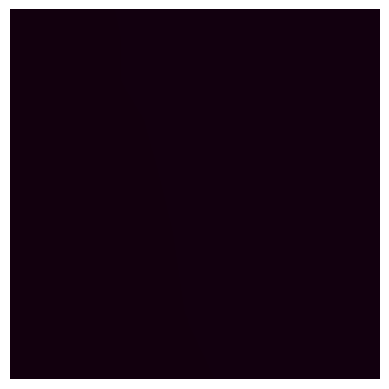

In [105]:
# Μην πειράξετε την αρχιτεκτονική
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def Net():
    return nn.Sequential(
        nn.Linear(2, 20),
        nn.ReLU(),
        nn.Linear(20, 20),
        nn.ReLU(),
        nn.Linear(20, 20),
        nn.ReLU(),
        nn.Linear(20, 20),
        nn.ReLU(),
        nn.Linear(20, 20),
        nn.ReLU(),
        nn.Linear(20, 20),
        nn.ReLU(),
        nn.Linear(20, 3)
    )

net = Net()
function2image(net)

In [106]:
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn

def train_model(model, train_loader, epochs):
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.MSELoss()
    # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    
    for epoch in range(epochs):
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        # scheduler.step()
        if epoch%10==0:
            print(f"epoch {epoch}\loss: {total_loss/len(train_loader)}")

<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Manos\AppData\Local\Temp\ipykernel_11484\3797239704.py:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  print(f"epoch {epoch}\loss: {total_loss/len(train_loader)}")


In [107]:
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

def generate_ds(f, samples=50):
    steps = np.linspace(0, 1, samples)
    inputs = []
    targets = []
    for i in steps:
        for j in steps:
            inputs.append([i, j])
            targets.append(f(i, j))

    inputs = torch.tensor(inputs, dtype=torch.float32)
    targets = torch.tensor(targets, dtype=torch.float32)

    # Keep inputs and RGB targets separate.
    # The notebook bug came from trying to stack tensors of shape (N, 2) and (N, 3).
    return TensorDataset(inputs, targets)

In [108]:
ds = generate_ds(basic_f, 100)


Task: basic
epoch 0\loss: 0.10665131229907274
epoch 10\loss: 1.4575954605788865e-05
epoch 20\loss: 1.5898186848062324e-05
epoch 30\loss: 2.875313185768391e-06
epoch 40\loss: 1.7305762196428986e-05
epoch 50\loss: 2.474513789252342e-06
epoch 60\loss: 9.250007815353456e-06
epoch 70\loss: 1.9798341227783568e-06
epoch 80\loss: 1.7868776453155989e-06
epoch 90\loss: 2.4670778935842462e-05


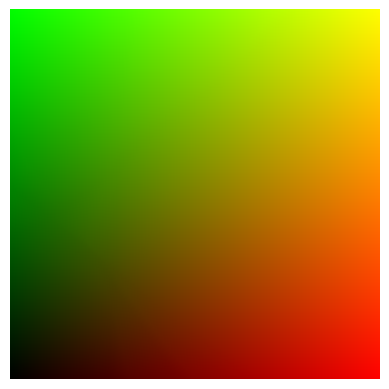

Task: easy
epoch 0\loss: 0.027236648183315993
epoch 10\loss: 4.118292960697545e-06
epoch 20\loss: 8.687322093692273e-06
epoch 30\loss: 1.6606525758078306e-06
epoch 40\loss: 3.1909482611780504e-07
epoch 50\loss: 3.6440287011885173e-06
epoch 60\loss: 6.853187060329447e-06
epoch 70\loss: 1.1199390777960616e-05
epoch 80\loss: 6.849788382279342e-07
epoch 90\loss: 3.8989638939668225e-06


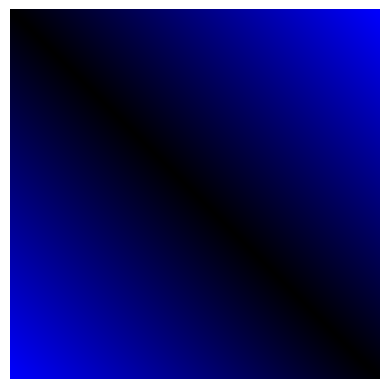

Task: medium
epoch 0\loss: 0.12747789587184882
epoch 10\loss: 0.024243370540867185
epoch 20\loss: 0.0005715564456857313
epoch 30\loss: 0.00042271561224375417
epoch 40\loss: 0.00030721047545403577
epoch 50\loss: 0.00027860644563385966
epoch 60\loss: 0.0002769232650842091
epoch 70\loss: 0.0002464926855380582
epoch 80\loss: 0.0002468007862876365
epoch 90\loss: 0.0002187538952648248
epoch 100\loss: 0.0002163374990411696
epoch 110\loss: 0.00022538261455454074
epoch 120\loss: 0.0002279470780913297
epoch 130\loss: 0.00020412725090029928
epoch 140\loss: 0.00020451881304742162
epoch 150\loss: 0.00019863309721673014
epoch 160\loss: 0.00021086066830043154
epoch 170\loss: 0.00019751520815177874
epoch 180\loss: 0.00020395277339036748
epoch 190\loss: 0.00022922383616144536
epoch 200\loss: 0.00021521510458276993
epoch 210\loss: 0.00017969548091615676
epoch 220\loss: 0.00019268278010481683
epoch 230\loss: 0.00017495893455810467
epoch 240\loss: 0.00017695092774258785


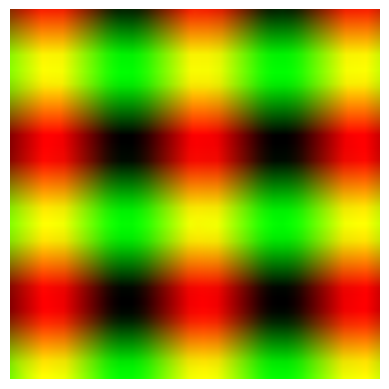

Task: advanced
epoch 0\loss: 0.18736982487948836
epoch 10\loss: 0.05469459926436661
epoch 20\loss: 0.045502167669640985
epoch 30\loss: 0.03999137009974498
epoch 40\loss: 0.035740859059106775
epoch 50\loss: 0.03310712756719559
epoch 60\loss: 0.03009927938366012
epoch 70\loss: 0.02724531780524998
epoch 80\loss: 0.025181916038132017
epoch 90\loss: 0.023800460847130247
epoch 100\loss: 0.022689117854283115
epoch 110\loss: 0.02228715713284198
epoch 120\loss: 0.022146413915428768
epoch 130\loss: 0.02177524369708292
epoch 140\loss: 0.019900520355885576
epoch 150\loss: 0.019726860479327143
epoch 160\loss: 0.018683056489439905
epoch 170\loss: 0.01856557076357922
epoch 180\loss: 0.017965842560408223
epoch 190\loss: 0.01833707539685023
epoch 200\loss: 0.017066328299890278
epoch 210\loss: 0.017370562211485804
epoch 220\loss: 0.018059114925563335
epoch 230\loss: 0.01660974489252089
epoch 240\loss: 0.01741587693927584
epoch 250\loss: 0.017223000751843878
epoch 260\loss: 0.016672020285704713
epoch 270

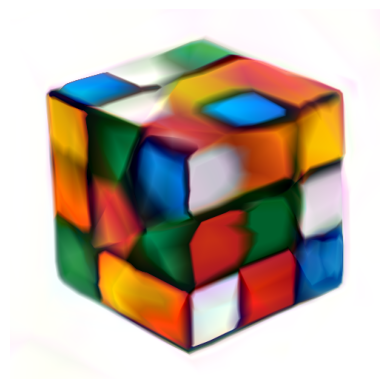

Task: hard
epoch 0\loss: 0.08607051720974421
epoch 10\loss: 0.011724788432169442
epoch 20\loss: 0.008577808523738776
epoch 30\loss: 0.007190373784984753
epoch 40\loss: 0.006322445070389846
epoch 50\loss: 0.006103376469885309
epoch 60\loss: 0.005675333098160347
epoch 70\loss: 0.005422029640723133
epoch 80\loss: 0.005183550590329399
epoch 90\loss: 0.005147324461075995
epoch 100\loss: 0.005073024604394279
epoch 110\loss: 0.0048379927069287405
epoch 120\loss: 0.004802688768114707
epoch 130\loss: 0.004880841928440137
epoch 140\loss: 0.004632458574082138
epoch 150\loss: 0.0046367741465060544
epoch 160\loss: 0.004490903227100845
epoch 170\loss: 0.004426297431839912
epoch 180\loss: 0.004185303828133402
epoch 190\loss: 0.0043198695309892895
epoch 200\loss: 0.004215748192780096
epoch 210\loss: 0.004073361352302435
epoch 220\loss: 0.0041059551506557245
epoch 230\loss: 0.00406562384909414
epoch 240\loss: 0.0039731452613128255
epoch 250\loss: 0.003964309376015356
epoch 260\loss: 0.00390049150434670

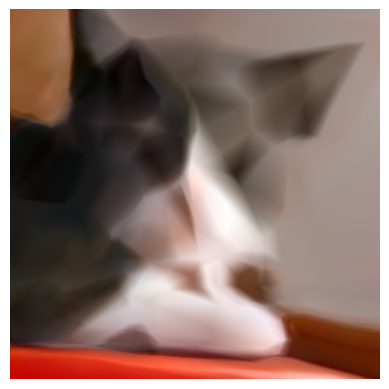

In [109]:
# TODO: Υλοποιήστε τον κώδικα εκπαίδευσης του νευρωνικού για κάθε μία από τις συναρτήσεις στόχους

tasks = {
    "basic":    basic_f,
    "easy":     easy_f,
    "medium":   medium_f,
    "advanced": advanced_f,
    "hard":     hard_f
}
epochs = {
    "basic":    100,
    "easy":     100,
    "medium":   250,
    "advanced": 300,
    "hard":     350
}
ds_sizes = {
    "basic":    100,
    "easy":     100,
    "medium":   200,
    "advanced": 200,
    "hard":     225
}
nets = {}
for task in tasks:
    print(f"Task: {task}")
    net = Net()
    ds = generate_ds(tasks[task], ds_sizes[task])
    dataloader = DataLoader(ds, batch_size=256, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
    train_model(net, dataloader, epochs[task])
    nets[task] = net
    function2image(net.to("cpu"))

    # TODO: Εκπαιδεύστε το νευρωνικό για κάθε task

## Υποβολή

Παίρνουμε τα βάρη του νευρωνικού για υποβολή στο site.

In [110]:
import json
def export_weights(net):
    layers = []
    i = 0
    while 2 * i < len(net):
        layer = net[2 * i]
        if isinstance(layer, torch.nn.Linear):
            weight_data = layer.weight.data.cpu().numpy()  # Shape: (num_outputs, num_inputs)
            bias_data = layer.bias.data.cpu().numpy()  # Shape: (num_outputs,)

            weights = weight_data.tolist()
            bias = bias_data.tolist()

            layers.append({
                "weights": weights,
                "bias": bias
            })
        i += 1

    return {"layers": layers}

def export_all_levels(nets, filename="answer.json"):
    result = {}

    for level in ["basic", "easy", "medium", "advanced", "hard"]:
        if level in nets:
            result[level] = export_weights(nets[level])

    with open(filename, 'w') as f:
        json.dump(result, f)

export_all_levels(nets)